In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

In [2]:
df1 = pd.read_csv('../grid_data/grids.csv',index_col=0)
df2 = pd.read_csv('../data_process/MDA8_2019.csv',index_col=0)
df3 = pd.read_csv('../data_fusion/sites.csv',index_col=0)
df2['cmaq_8_max']=df2['cmaq_8_max']*0.467 #ppb to mg/m3

In [ ]:
dfa1 = pd.read_csv('./appendix/gridsearch_rf_pred.csv',index_col=0)
dfa2 = pd.read_csv('./appendix/gridsearch_xgboost_pred.csv',index_col=0)

In [4]:
dfa1=dfa1[['index','time','prediction_1']]
dfa2=dfa2[['index','time','prediction_1']]

In [5]:
dfa2['prediction_2'] = dfa2.pop('prediction_1')

In [ ]:
df23 =pd.merge(df2,df3,left_on='sites',right_on='0',how='left')

df23_lat_lon = df23[['1', '2']].values  
df1_lat_lon = df1[['lat', 'lon']].values  

distance_matrix = cdist(df23_lat_lon, df1_lat_lon, metric='euclidean')

nearest_indices = np.argmin(distance_matrix, axis=1)

df23['nearest_index'] = nearest_indices

print(df23)

              time    sites  obs_8_max  cmaq_8_max        0          1  \
0       2019-01-04  betb004  23.785714   24.088142  betb004  50.852051   
1       2019-01-04  betb011  38.357143   21.274522  betb011  50.857806   
2       2019-01-04  betm705  44.625000   28.532625  betm705  50.945359   
3       2019-01-04  betmeu1  30.562500   20.593653  betmeu1  50.895001   
4       2019-01-04  betn012  57.000000   28.529405  betn012  51.254574   
...            ...      ...        ...         ...      ...        ...   
123944  2019-12-30  nl00818  23.152500   21.637031  nl00818  52.654144   
123945  2019-12-30  nl00918  17.515000   22.640592  nl00918  52.916915   
123946  2019-12-30  nl00929  27.338750   27.460588  nl00929  52.875725   
123947  2019-12-30  nl00934  24.090000   23.561920  nl00934  53.330425   
123948  2019-12-30  nl00938  31.222500   23.377043  nl00938  53.246535   

               2 country  nearest_index  
0       4.347778      be            116  
1       4.288706      be   

In [7]:
dfa1['time'] = pd.to_datetime(dfa1['time'])
dfa2['time'] = pd.to_datetime(dfa2['time'])
df23['time'] = pd.to_datetime(df23['time'])

In [8]:
merged_df = pd.merge(df23, dfa1, how='left', left_on=['time','nearest_index'], right_on=['time','index'])

In [9]:
merged_df =pd.merge(merged_df,dfa2,on=['time','index'])

In [10]:
df_results=merged_df.dropna()

In [11]:
rmse_value_a1 = np.round(((df_results['obs_8_max'] - df_results['prediction_1']) ** 2).mean() ** 0.5, 2)
r2_value_a1 = r2_score(df_results['obs_8_max'], df_results['prediction_1'])
pearson_corr_a1 = np.round((df_results['obs_8_max'].corr(df_results['prediction_1']) ), 2)
mae_value_a1 = np.round((df_results['obs_8_max'] - df_results['prediction_1']).abs().mean(), 2)

In [12]:
rmse_value_a2 = np.round(((df_results['obs_8_max'] - df_results['prediction_2']) ** 2).mean() ** 0.5, 2)
r2_value_a2 = r2_score(df_results['obs_8_max'], df_results['prediction_2'])
pearson_corr_a2 = np.round((df_results['obs_8_max'].corr(df_results['prediction_2']) ), 2)
mae_value_a2 = np.round((df_results['obs_8_max'] - df_results['prediction_2']).abs().mean(), 2)

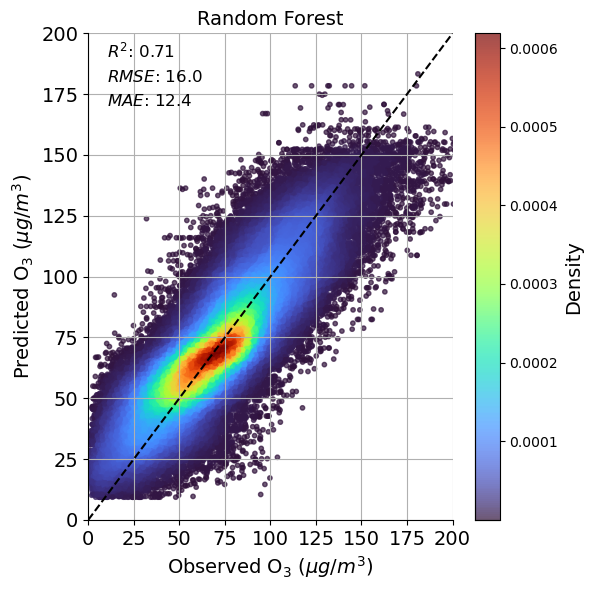

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


a = df_results['obs_8_max']
b = df_results['prediction_1']
xy = np.vstack([a, b])
z = gaussian_kde(xy)(xy)


plt.figure(figsize=(6, 6))
scatter_plot=plt.scatter(a, b, c=z, s=10, cmap='turbo', alpha=0.7)
plt.title("Random Forest", fontsize=14)
plt.plot([0, 200], [0, 200], color="black", linestyle='--')

plt.xlim(0, 200)
plt.ylim(0, 200)


plt.xlabel(r'Observed $\text{O}_{3}$ ($\mu g/m^{3}$)', fontsize=14)
plt.ylabel(r'Predicted $\text{O}_{3}$ ($\mu g/m^{3}$)', fontsize=14)

plt.text(0.05, 0.95, f"$R^2$: {r2_value_a1:.2f}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.9, f"$RMSE$: {rmse_value_a1:.1f}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.85, f"$MAE$: {mae_value_a1:.1f}", transform=plt.gca().transAxes, fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(scatter_plot)
cbar.set_label('Density',fontsize=14)

sns.despine()
plt.grid()

plt.tight_layout()
plt.show()

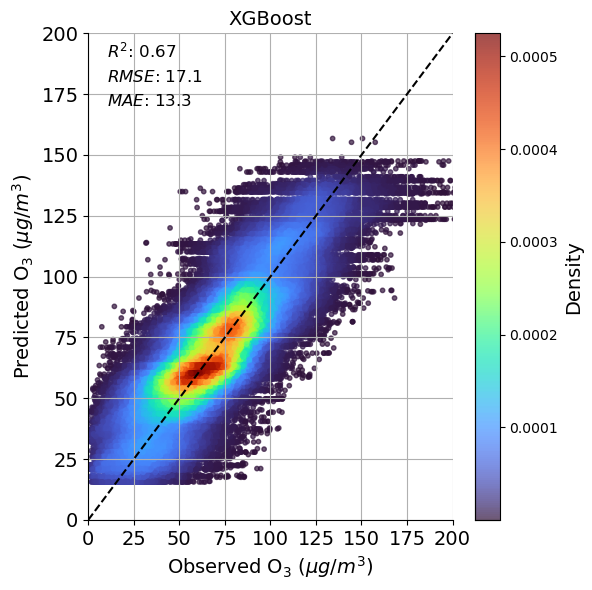

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

a = df_results['obs_8_max']
b = df_results['prediction_2']
xy = np.vstack([a, b])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(6, 6))
scatter_plot=plt.scatter(a, b, c=z, s=10, cmap='turbo', alpha=0.7)
plt.title("XGBoost", fontsize=14)
plt.plot([0, 200], [0, 200], color="black", linestyle='--')

plt.xlim(0, 200)
plt.ylim(0, 200)

plt.xlabel(r'Observed $\text{O}_{3}$ ($\mu g/m^{3}$)', fontsize=14)
plt.ylabel(r'Predicted $\text{O}_{3}$ ($\mu g/m^{3}$)', fontsize=14)

plt.text(0.05, 0.95, f"$R^2$: {r2_value_a2:.2f}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.9, f"$RMSE$: {rmse_value_a2:.1f}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.05, 0.85, f"$MAE$: {mae_value_a2:.1f}", transform=plt.gca().transAxes, fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(scatter_plot)
cbar.set_label('Density',fontsize=14)

sns.despine()
plt.grid()

plt.tight_layout()
plt.show()